In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz
import xarray as xr
from scipy.interpolate import PchipInterpolator
from scipy.stats import linregress

In [2]:
np.random.seed(123)

In [3]:
bikes = pd.read_csv('data/bikes.csv')
bikes

,rented,hour,temperature,humidity,windspeed,weekday
0,16,0,3.28,0.81,0.0000,6
1,3,5,-0.48,0.47,0.2836,1
2,115,9,2.34,0.37,0.3284,3
3,73,13,1.40,0.37,0.2836,5
4,82,15,2.34,0.35,0.3582,0
...,...,...,...,...,...,...
343,90,9,4.22,0.48,0.3881,6
344,135,12,5.16,0.56,0.0896,1
345,13,15,4.22,0.87,0.3582,3
346,271,17,3.28,0.60,0.1343,5


<Axes: xlabel='temperature', ylabel='rented'>

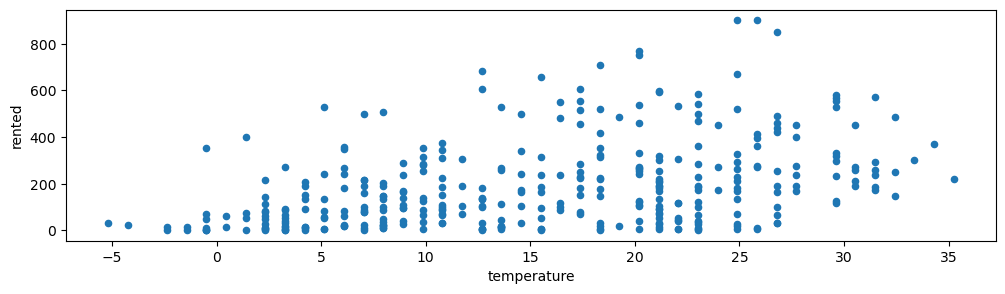

In [4]:
bikes.plot(x='temperature', y='rented', kind='scatter', figsize=(12, 3))

In [5]:
with pm.Model() as model_lb:
    alpha = pm.Normal("alpha", mu=0, sigma=100)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfCauchy("sigma", 10)
    mu = pm.Deterministic("mu", alpha + beta * bikes.temperature)
    y_pred = pm.Normal("y_pred", mu=mu, sigma=sigma, observed=bikes.rented)
    idata_lb = pm.sample(random_seed=123)
    

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [6]:
idata_lb

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

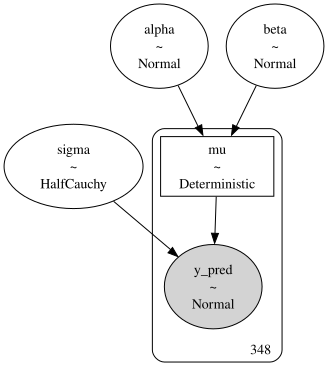

In [7]:
pm.model_to_graphviz(model_lb)

array([<Axes: title={'center': 'alpha'}>,
       <Axes: title={'center': 'beta'}>,
       <Axes: title={'center': 'sigma'}>], dtype=object)

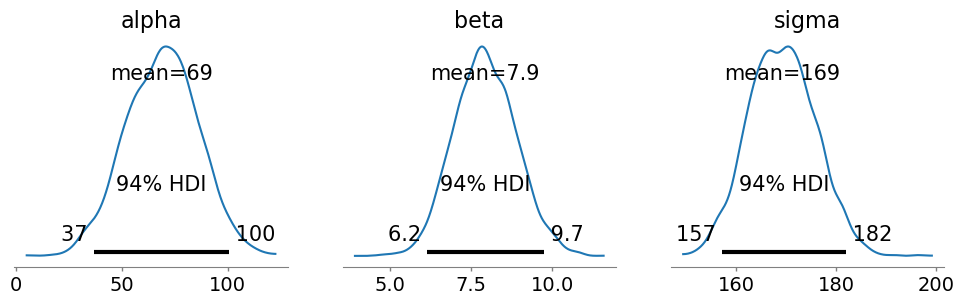

In [8]:
az.plot_posterior(idata_lb, var_names=["~mu"], figsize=(12,3))

In [9]:
# chain과 draw 차원을 하나의 sample 차원으로 스택
posterior = az.extract(idata_lb, num_samples=50)
posterior


<xarray.Dataset>
Dimensions:   (sample: 50, mu_dim_0: 348)
Coordinates:
  * mu_dim_0  (mu_dim_0) int64 0 1 2 3 4 5 6 7 ... 341 342 343 344 345 346 347
  * sample    (sample) object MultiIndex
  * chain     (sample) int64 3 3 0 2 2 2 2 1 2 2 0 2 ... 3 2 2 1 0 2 2 0 1 3 0 2
  * draw      (sample) int64 269 212 991 476 617 491 ... 867 507 836 194 453 543
Data variables:
    alpha     (sample) float64 71.75 56.75 56.44 57.51 ... 94.12 76.38 57.1
    beta      (sample) float64 7.183 8.871 9.394 8.485 ... 7.596 8.235 8.651
    sigma     (sample) float64 178.2 164.2 187.8 176.4 ... 167.4 161.1 171.5
    mu        (mu_dim_0, sample) float64 95.31 85.85 87.25 ... 154.7 142.1 126.1
Attributes:
    created_at:                 2025-04-17T09:17:40.317702
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.8.0
    sampling_time:              3.8896541595458984
    tuning_steps:               1000

In [10]:
np.linspace(bikes.temperature.min(), bikes.temperature.max(), 50)

array([-5.18      , -4.35510204, -3.53020408, -2.70530612, -1.88040816,
       -1.0555102 , -0.23061224,  0.59428571,  1.41918367,  2.24408163,
        3.06897959,  3.89387755,  4.71877551,  5.54367347,  6.36857143,
        7.19346939,  8.01836735,  8.84326531,  9.66816327, 10.49306122,
       11.31795918, 12.14285714, 12.9677551 , 13.79265306, 14.61755102,
       15.44244898, 16.26734694, 17.0922449 , 17.91714286, 18.74204082,
       19.56693878, 20.39183673, 21.21673469, 22.04163265, 22.86653061,
       23.69142857, 24.51632653, 25.34122449, 26.16612245, 26.99102041,
       27.81591837, 28.64081633, 29.46571429, 30.29061224, 31.1155102 ,
       31.94040816, 32.76530612, 33.59020408, 34.41510204, 35.24      ])

In [11]:
x_plot = xr.DataArray(
    np.linspace(bikes.temperature.min(), bikes.temperature.max(), 50), dims="plot_id"
)
x_plot

<xarray.DataArray (plot_id: 50)>
array([-5.18      , -4.35510204, -3.53020408, -2.70530612, -1.88040816,
       -1.0555102 , -0.23061224,  0.59428571,  1.41918367,  2.24408163,
        3.06897959,  3.89387755,  4.71877551,  5.54367347,  6.36857143,
        7.19346939,  8.01836735,  8.84326531,  9.66816327, 10.49306122,
       11.31795918, 12.14285714, 12.9677551 , 13.79265306, 14.61755102,
       15.44244898, 16.26734694, 17.0922449 , 17.91714286, 18.74204082,
       19.56693878, 20.39183673, 21.21673469, 22.04163265, 22.86653061,
       23.69142857, 24.51632653, 25.34122449, 26.16612245, 26.99102041,
       27.81591837, 28.64081633, 29.46571429, 30.29061224, 31.1155102 ,
       31.94040816, 32.76530612, 33.59020408, 34.41510204, 35.24      ])
Dimensions without coordinates: plot_id

In [12]:
idx = np.argsort(bikes.temperature.values)
idx

array([ 10, 193,  19,   6,  18,  24, 180, 174,  11, 183,   1,   5, 163,
        12,  13, 204,  14, 164,   3,  40,   2, 197, 177, 152, 206,   8,
       330, 339,  15, 162,   4, 346,  38, 172,  41,  39, 175,   0, 149,
        32, 196,  28, 329,   7,   9, 345, 343, 186, 179, 182, 194, 187,
       344, 166, 185, 328, 173,  16,  26,  30, 319, 190, 318, 170, 338,
       195, 342,  33, 192, 325, 321, 171, 227, 320,  27, 184,  17, 331,
       158, 160, 159, 326, 214, 191,  31, 146, 340,  42, 347,  45, 333,
       228,  52, 310,  23,  25, 178, 169, 142, 167, 217, 219, 312, 327,
       332, 337, 200, 207, 140, 229, 336,  21, 148, 147, 341,  20, 139,
       202, 165,  36, 308, 176, 189, 154, 199, 143, 230, 130, 129,  34,
       203, 216, 198, 201, 225,  47,  51, 299, 168, 218,  49, 153, 150,
       213, 205, 322, 309,  37, 335, 314, 301, 161, 209, 181,  50, 239,
       151,  61,  44, 155, 145, 137,  48, 141,  29, 307, 235,  62, 144,
       156, 222,  63, 240, 138, 136,  56, 226, 122, 324,  46,  6

In [13]:
posterior.alpha

<xarray.DataArray 'alpha' (sample: 50)>
array([ 71.74862757,  56.75066857,  56.43672134,  57.50884134,
        69.36643988,  48.62917668,  40.44103678,  94.96256564,
        76.22620463,  88.89855327,  58.78729801,  94.14473963,
        68.74637415,  79.95441267,  70.74045926,  85.46233967,
        83.60498404,  99.14099177, 111.42171428,  62.09797004,
       106.67808099,  75.16358628,  58.75719905,  70.12714334,
        76.90865551,  63.72468178,  69.17464611,  50.41526111,
        74.03895   ,  88.76311009,  24.54132058,  70.43492947,
        41.0345583 ,  99.9458157 , 119.20304168,  66.24270113,
        63.94272261,  59.1560309 ,  99.18570584,  73.30842165,
        81.13366305,  78.74266385,  52.08083727,  46.41423307,
        55.36878965,  67.2971075 ,  68.4737636 ,  94.12398225,
        76.37953049,  57.09967872])
Coordinates:
  * sample   (sample) object MultiIndex
  * chain    (sample) int64 3 3 0 2 2 2 2 1 2 2 0 2 ... 3 2 2 1 0 2 2 0 1 3 0 2
  * draw     (sample) int64 269 212 991 476 617 491 ... 867 507 836 194 453 543

In [14]:
posterior.beta

<xarray.DataArray 'beta' (sample: 50)>
array([ 7.18333128,  8.8708194 ,  9.39420515,  8.48539841,  7.72455414,
        8.75307411,  9.24572247,  6.88145712,  7.33510947,  7.10772104,
        8.03777017,  5.76652553,  7.63948112,  6.70564028,  8.03094483,
        6.77524583,  7.72977825,  6.32821349,  6.39334264,  8.64898324,
        6.10300451,  7.18542278,  8.15014785,  7.74498005,  7.14667608,
        7.32490055,  8.542697  ,  8.71656037,  7.68544351,  7.0896055 ,
       10.44549804,  8.81549274,  9.1619366 ,  6.34627629,  6.01867857,
        8.46215427,  8.94243922,  8.11153459,  6.43413306,  7.7781488 ,
        7.83240703,  6.51410287,  8.44415308,  8.48306391,  8.14179661,
        7.48601567,  7.4404245 ,  7.59640667,  8.23474893,  8.65122734])
Coordinates:
  * sample   (sample) object MultiIndex
  * chain    (sample) int64 3 3 0 2 2 2 2 1 2 2 0 2 ... 3 2 2 1 0 2 2 0 1 3 0 2
  * draw     (sample) int64 269 212 991 476 617 491 ... 867 507 836 194 453 543

In [15]:
mean_line = posterior["alpha"].mean() + posterior["beta"].mean() * x_plot
mean_line

<xarray.DataArray (plot_id: 50)>
array([ 31.8548365 ,  38.25715654,  44.65947658,  51.06179662,
        57.46411667,  63.86643671,  70.26875675,  76.6710768 ,
        83.07339684,  89.47571688,  95.87803692, 102.28035697,
       108.68267701, 115.08499705, 121.4873171 , 127.88963714,
       134.29195718, 140.69427722, 147.09659727, 153.49891731,
       159.90123735, 166.30355739, 172.70587744, 179.10819748,
       185.51051752, 191.91283757, 198.31515761, 204.71747765,
       211.11979769, 217.52211774, 223.92443778, 230.32675782,
       236.72907787, 243.13139791, 249.53371795, 255.93603799,
       262.33835804, 268.74067808, 275.14299812, 281.54531817,
       287.94763821, 294.34995825, 300.75227829, 307.15459834,
       313.55691838, 319.95923842, 326.36155846, 332.76387851,
       339.16619855, 345.56851859])
Dimensions without coordinates: plot_id

In [16]:
lines = posterior["alpha"] + posterior['beta'] * x_plot
lines

<xarray.DataArray (sample: 50, plot_id: 50)>
array([[ 34.53897157,  40.46448687,  46.39000218, ..., 313.0381911 ,
        318.96370641, 324.88922172],
       [ 10.79982409,  18.11734491,  25.43486572, ..., 354.72330249,
        362.0408233 , 369.35834412],
       [  7.77473868,  15.52399933,  23.27325999, ..., 371.98998943,
        379.73925008, 387.48851074],
       ...,
       [ 54.7745957 ,  61.04085606,  67.30711642, ..., 349.28883257,
        355.55509293, 361.82135329],
       [ 33.72353106,  40.51635864,  47.30918622, ..., 352.98642749,
        359.77925507, 366.57208266],
       [ 12.28632112,  19.42270089,  26.55908067, ..., 347.69617053,
        354.83255031, 361.96893008]])
Coordinates:
  * sample   (sample) object MultiIndex
  * chain    (sample) int64 3 3 0 2 2 2 2 1 2 2 0 2 ... 3 2 2 1 0 2 2 0 1 3 0 2
  * draw     (sample) int64 269 212 991 476 617 491 ... 867 507 836 194 453 543
Dimensions without coordinates: plot_id

In [17]:
hdi_lines = az.hdi(idata_lb.posterior["mu"])
hdi_lines

<xarray.Dataset>
Dimensions:   (mu_dim_0: 348, hdi: 2)
Coordinates:
  * mu_dim_0  (mu_dim_0) int64 0 1 2 3 4 5 6 7 ... 341 342 343 344 345 346 347
  * hdi       (hdi) <U6 'lower' 'higher'
Data variables:
    mu        (mu_dim_0, hdi) float64 68.43 122.8 32.46 ... 122.8 112.1 154.7

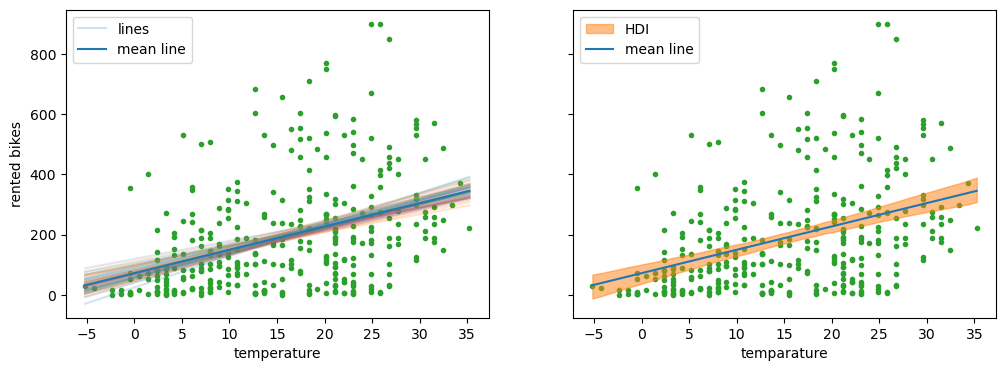

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)
lines_ = axes[0].plot(x_plot, lines.T, alpha=0.2, label="lines")
plt.setp(lines_[1:], label="_")
axes[0].plot(x_plot, mean_line, label="mean line")
axes[0].set_xlabel("temperature")
axes[0].set_ylabel("rented bikes")
axes[0].legend()

axes[1].plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)
idx = np.argsort(bikes.temperature.values)
axes[1].fill_between(bikes.temperature[idx], 
                     hdi_lines['mu'][:, 0][idx],
                     hdi_lines['mu'][:, 1][idx],
                     color="C1",
                     label="HDI",
                     alpha=0.5)
axes[1].plot(x_plot, mean_line, label="mean line")
axes[1].set_xlabel("temparature")
axes[1].legend()
                     

In [19]:
pm.sample_posterior_predictive(idata_lb, model=model_lb, extend_inferencedata=True)
idata_lb

Sampling: [y_pred]


Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [20]:
mean_line = idata_lb.posterior["mu"].mean(("chain", "draw"))
mean_line

<xarray.DataArray 'mu' (mu_dim_0: 348)>
array([ 94.93612487,  65.0900644 ,  87.47460975,  80.01309463,
        87.47460975,  65.0900644 ,  50.16703417, 102.39763998,
        87.47460975, 102.39763998,  27.78248882,  65.0900644 ,
        72.55157952,  72.55157952,  80.01309463,  87.47460975,
       109.8591551 , 124.78218533,  57.62854928,  50.16703417,
       147.16673068, 147.16673068, 251.62794232, 132.24370045,
        57.62854928, 132.24370045, 109.8591551 , 124.78218533,
        94.93612487, 184.47430627, 109.8591551 , 132.24370045,
        94.93612487, 117.32067022, 154.6282458 , 259.08945744,
       154.6282458 , 169.55127603,  94.93612487,  94.93612487,
        87.47460975,  94.93612487, 132.24370045, 229.24339697,
       177.01279115, 132.24370045, 199.3973365 , 162.08976092,
       184.47430627, 169.55127603, 177.01279115, 169.55127603,
       132.24370045, 214.32036673, 236.70491208, 214.32036673,
       191.93582138, 274.01248767, 214.32036673, 214.32036673,
       199.3973365 , 177.01279115, 191.93582138, 191.93582138,
       199.3973365 , 206.85885162, 244.1664272 , 288.9355179 ,
       311.32006325, 288.9355179 , 326.24309349, 281.47400279,
       236.70491208, 236.70491208, 244.1664272 , 251.62794232,
       236.70491208, 221.78188185, 251.62794232, 281.47400279,
...
       348.62763884, 318.78157837, 229.24339697, 303.85854814,
       274.01248767, 288.9355179 , 266.55097255, 244.1664272 ,
       251.62794232, 281.47400279, 266.55097255, 318.78157837,
       303.85854814, 311.32006325, 281.47400279, 281.47400279,
       236.70491208, 236.70491208, 244.1664272 , 244.1664272 ,
       251.62794232, 244.1664272 , 288.9355179 , 281.47400279,
       303.85854814, 303.85854814, 266.55097255, 236.70491208,
       236.70491208, 206.85885162, 229.24339697, 169.55127603,
       214.32036673, 177.01279115, 229.24339697, 251.62794232,
       236.70491208, 236.70491208, 266.55097255, 184.47430627,
       154.6282458 , 169.55127603, 132.24370045, 214.32036673,
       139.70521557, 206.85885162, 177.01279115, 229.24339697,
       214.32036673, 214.32036673, 117.32067022, 117.32067022,
       124.78218533, 124.78218533, 169.55127603, 206.85885162,
       199.3973365 , 117.32067022, 124.78218533, 139.70521557,
       109.8591551 ,  94.93612487,  87.47460975, 124.78218533,
       139.70521557, 132.24370045, 229.24339697, 169.55127603,
       147.16673068, 139.70521557, 117.32067022,  87.47460975,
       132.24370045, 147.16673068, 117.32067022, 102.39763998,
       109.8591551 , 102.39763998,  94.93612487, 132.24370045])
Coordinates:
  * mu_dim_0  (mu_dim_0) int64 0 1 2 3 4 5 6 7 ... 341 342 343 344 345 346 347

In [21]:
# 코드는 `bikes.temperature.values` 배열을 중심으로 평균이 동일하고 표준편차가 0.01인 정규분포에서 난수를 생성하여 새로운 `temperatures` 배열을 만듭니다. 이 배열은 원래 `bikes.temperature` 값들에 약간의 노이즈를 추가한 값들로 구성됩니다.
temperatures = np.random.normal(bikes.temperature.values, 0.01)
temperatures

array([ 3.26914369, -0.47002655,  2.34282978,  1.38493705,  2.334214  ,
       -0.46348563, -2.38426679,  4.21571087,  2.35265936,  4.2113326 ,
       -5.18678886, -0.48094709,  0.4749139 ,  0.45361098,  1.39556018,
        2.33565649,  5.1820593 ,  7.06186786, -1.40995946, -2.35613814,
        9.86737369,  9.87490732, 23.01064166,  7.99175829, -1.43253881,
        7.97362248,  5.16907105,  7.02571319,  3.27859931, 14.55138245,
        5.15744381,  7.95201411,  3.26228467,  6.09300123, 10.80927462,
       23.95826364, 10.80002846, 12.68688223,  3.27120464,  3.28283627,
        2.33194633,  3.26272331,  7.976091  , 20.20573806, 13.62338589,
        7.9798817 , 16.46392365, 11.74412912, 14.56978736, 12.70238143,
       13.60705915, 12.66961212,  7.99743712, 18.31201937, 21.14029683,
       18.33069316, 15.50890706, 25.85754886, 18.33495644, 18.33069393,
       16.43227291, 13.62794863, 15.50314272, 15.48673735, 16.45417299,
       17.38807237, 22.0804549 , 27.71766908, 30.52801699, 27.72

In [22]:
idx = np.argsort(temperatures)
idx

array([ 10, 193,   6,  19,  24,  18, 183,  11, 180, 174, 163,   1,   5,
        13,  12,   3,  14, 204, 164, 339, 152,  40, 177,   4,  15, 330,
       197, 206, 162,   2,   8,  32,  41,   0,  38, 172, 196,  28, 346,
       149,  39, 329, 175, 187,   9, 186,   7, 343, 345, 179, 194, 182,
       185, 344,  30, 328, 173,  26, 166,  16, 195, 170,  33, 325, 318,
       190, 192, 319, 342, 338, 326,  27, 227, 321, 320, 184, 159, 171,
       160, 158, 331,  17,  31, 228, 214,  25, 340, 178,  42, 333, 191,
        45, 347, 146,  23, 310,  52, 167, 312, 332, 327, 169, 219, 217,
       337, 200, 142, 207, 140, 341, 139, 148, 229, 336,  20,  21, 147,
       202, 230, 154, 130, 165, 129, 199,  36, 176, 143, 308, 189, 203,
       216,  34, 225, 201, 198,  47, 153, 213,  51, 218, 322, 335, 205,
       309, 168, 150,  37, 299,  49,  50, 301, 239, 161, 209, 151,  44,
        61, 314, 181,  29, 145, 141, 155, 307,  48, 137,  63, 136, 235,
       222, 240,  62, 156, 144,  56, 138, 226,  60, 122, 324,  6

In [23]:
x = np.linspace(temperatures.min(), temperatures.max(), 15)
x

array([-5.18678886, -2.29829038,  0.5902081 ,  3.47870658,  6.36720506,
        9.25570354, 12.14420202, 15.0327005 , 17.92119898, 20.80969746,
       23.69819594, 26.58669442, 29.4751929 , 32.36369138, 35.25218986])

In [24]:
y_pred_q = idata_lb.posterior_predictive["y_pred"].quantile([0.03, 0.97, 0.25, 0.75], 
                                                            dim=['chain', 'draw'])
y_pred_q

<xarray.DataArray 'y_pred' (quantile: 4, y_pred_dim_2: 348)>
array([[-219.02703447, -262.14174342, -237.72668729, ..., -215.8632199 ,
        -235.24078366, -175.04006804],
       [ 428.78774964,  371.50120209,  411.83154953, ...,  420.46358135,
         412.3546546 ,  450.97624121],
       [ -19.0241388 ,  -49.1552805 ,  -27.8645035 , ...,  -11.9991083 ,
         -20.18289761,   18.38898755],
       [ 210.31432719,  181.77803674,  207.18978103, ...,  213.00920009,
         202.18561088,  247.60470578]])
Coordinates:
  * y_pred_dim_2  (y_pred_dim_2) int64 0 1 2 3 4 5 6 ... 342 343 344 345 346 347
  * quantile      (quantile) float64 0.03 0.97 0.25 0.75

In [25]:
[
    PchipInterpolator(temperatures[idx], y_pred_q[i][idx])(x)
        for i in range(4)
]

[array([-289.91057239, -272.27294312, -242.42331592, -221.86601228,
        -202.0984657 , -196.47619792, -157.66452449, -124.89024575,
        -109.95851624,  -98.79724421,  -73.77684439,  -34.90370366,
         -28.2654587 ,   -2.70202171,   34.08699995]),
 array([358.99347549, 376.09449786, 386.7086141 , 421.47361182,
        426.74602878, 462.8956905 , 485.47773412, 512.08992103,
        530.05891484, 544.65671895, 562.39901731, 593.06318946,
        627.44747303, 650.86834347, 669.82934821]),
 array([-80.14813589, -66.71000493, -37.03901554, -15.31463655,
          0.7336651 ,  23.21127501,  54.53858305,  76.90899948,
         97.63910285, 117.8044663 , 145.97096395, 167.85894356,
        189.0247776 , 212.97362433, 227.28446219]),
 array([145.27910647, 160.1205249 , 187.64974949, 211.67021257,
        230.23025969, 264.20196748, 284.20693704, 307.69133092,
        326.64122565, 351.36411343, 374.04272305, 399.24871082,
        422.54231553, 441.90312365, 460.42107356])]

In [26]:
y_hat_bounds = iter(
    [
        # PchipInterpolator는 주어진 데이터를 기반으로 1차원 단조(monotonic) 보간(interpolation)을 수행하는 클래스
        PchipInterpolator(temperatures[idx], y_pred_q[i][idx])(x)
        for i in range(4)
    ]
)

y_hat_bounds

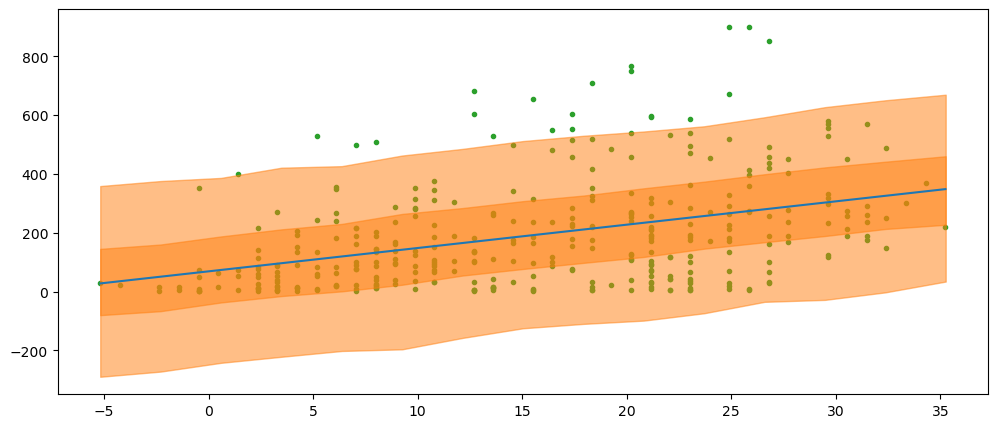

In [27]:
_, ax = plt.subplots(figsize=(12, 5))
ax.plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)
ax.plot(bikes.temperature[idx], mean_line[idx], c="C0")

for lb, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(x, lb, ub, color="C1", alpha=0.5)

In [28]:
with pm.Model() as model_neg:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal('sigma', 10)
    # 실수 범위를 양의 구간으로 변환 위해 exp 사용
    mu = pm.Deterministic("mu", pm.math.exp(alpha + beta * bikes.temperature))
    y_pred = pm.NegativeBinomial("y_pred", mu=mu, alpha=sigma, observed=bikes.rented)
    
    idata_neg = pm.sample()
    idata_neg.extend(pm.sample_posterior_predictive(idata_neg))

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
Sampling: [y_pred]


In [29]:
idata_neg

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [30]:
mean_line = idata_neg.posterior["mu"].mean(("chain", "draw"))
mean_line

<xarray.DataArray 'mu' (mu_dim_0: 348)>
array([ 94.688509  ,  78.37528961,  90.3118609 ,  86.14054357,
        90.3118609 ,  78.37528961,  71.32009968,  99.28075415,
        90.3118609 ,  99.28075415,  61.92641684,  78.37528961,
        82.16478629,  82.16478629,  86.14054357,  90.3118609 ,
       104.09938361, 114.46171193,  74.76320235,  71.32009968,
       132.00582092, 132.00582092, 257.8888413 , 120.02983889,
        74.76320235, 120.02983889, 104.09938361, 114.46171193,
        94.688509  , 167.54070982, 104.09938361, 120.02983889,
        94.688509  , 109.15573248, 138.44202812, 270.59603984,
       138.44202812, 152.28725938,  94.688509  ,  94.688509  ,
        90.3118609 ,  94.688509  , 120.02983889, 223.28399272,
       159.72919992, 120.02983889, 184.34793852, 145.19715812,
       167.54070982, 152.28725938, 159.72919992, 152.28725938,
       120.02983889, 202.8697841 , 234.26134201, 202.8697841 ,
       175.74042585, 297.95114078, 202.8697841 , 202.8697841 ,
       184.34793852, 159.72919992, 175.74042585, 175.74042585,
       184.34793852, 193.38384157, 245.78702195, 328.11780169,
       379.29010179, 328.11780169, 417.83907942, 312.66536991,
       234.26134201, 234.26134201, 245.78702195, 257.8888413 ,
       234.26134201, 212.8285254 , 257.8888413 , 312.66536991,
...
       483.25903568, 398.09125948, 223.28399272, 361.38960525,
       297.95114078, 328.11780169, 283.93936307, 245.78702195,
       257.8888413 , 312.66536991, 283.93936307, 398.09125948,
       361.38960525, 379.29010179, 312.66536991, 312.66536991,
       234.26134201, 234.26134201, 245.78702195, 245.78702195,
       257.8888413 , 245.78702195, 328.11780169, 312.66536991,
       361.38960525, 361.38960525, 283.93936307, 234.26134201,
       234.26134201, 193.38384157, 223.28399272, 152.28725938,
       202.8697841 , 159.72919992, 223.28399272, 257.8888413 ,
       234.26134201, 234.26134201, 283.93936307, 167.54070982,
       138.44202812, 152.28725938, 120.02983889, 202.8697841 ,
       125.87326728, 193.38384157, 159.72919992, 223.28399272,
       202.8697841 , 202.8697841 , 109.15573248, 109.15573248,
       114.46171193, 114.46171193, 152.28725938, 193.38384157,
       184.34793852, 109.15573248, 114.46171193, 125.87326728,
       104.09938361,  94.688509  ,  90.3118609 , 114.46171193,
       125.87326728, 120.02983889, 223.28399272, 152.28725938,
       132.00582092, 125.87326728, 109.15573248,  90.3118609 ,
       120.02983889, 132.00582092, 109.15573248,  99.28075415,
       104.09938361,  99.28075415,  94.688509  , 120.02983889])
Coordinates:
  * mu_dim_0  (mu_dim_0) int64 0 1 2 3 4 5 6 7 ... 341 342 343 344 345 346 347

In [31]:
y_pred_q = idata_neg.posterior_predictive["y_pred"].quantile([0.03, 0.97, 0.25, 0.75], 
                                                            dim=['chain', 'draw'])
y_pred_q

<xarray.DataArray 'y_pred' (quantile: 4, y_pred_dim_2: 348)>
array([[  2.  ,   1.  ,   2.  , ...,   2.  ,   2.  ,   3.  ],
       [346.03, 264.  , 323.  , ..., 377.  , 336.  , 441.  ],
       [ 25.75,  21.  ,  24.  , ...,  27.  ,  26.  ,  34.  ],
       [127.  , 106.  , 124.  , ..., 135.  , 131.  , 164.  ]])
Coordinates:
  * y_pred_dim_2  (y_pred_dim_2) int64 0 1 2 3 4 5 6 ... 342 343 344 345 346 347
  * quantile      (quantile) float64 0.03 0.97 0.25 0.75

In [32]:
y_hat_bounds = iter(
    [
        # PchipInterpolator는 주어진 데이터를 기반으로 1차원 단조(monotonic) 보간(interpolation)을 수행하는 클래스
        PchipInterpolator(temperatures[idx], y_pred_q[i][idx])(x)
        for i in range(4)
    ]
)

y_hat_bounds

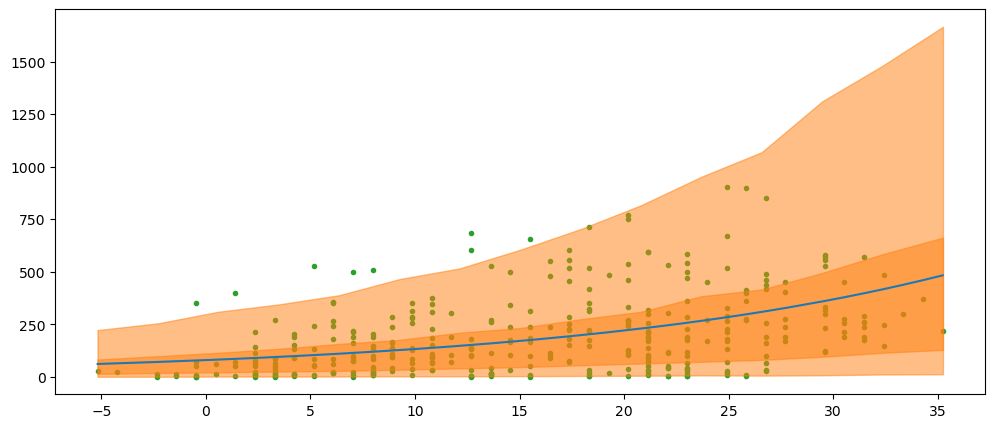

In [33]:
_, ax = plt.subplots(figsize=(12, 5))
ax.plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)
ax.plot(bikes.temperature[idx], mean_line[idx], c="C0")

for lb, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(x, lb, ub, color="C1", alpha=0.5)

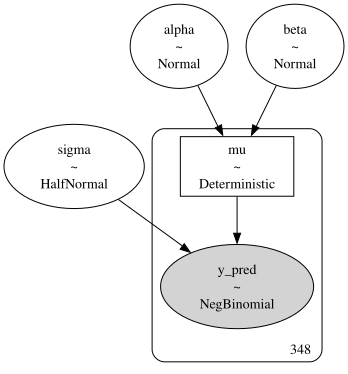

In [34]:
pm.model_to_graphviz(model_neg)

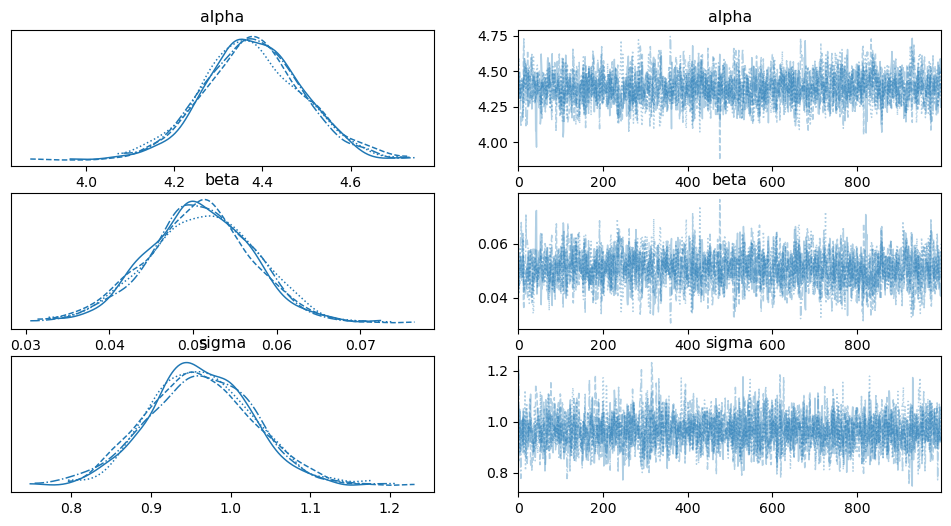

In [35]:
az.plot_trace(idata_neg, var_names=["~mu"]);

array([<Axes: xlabel='y_pred / y_pred'>], dtype=object)

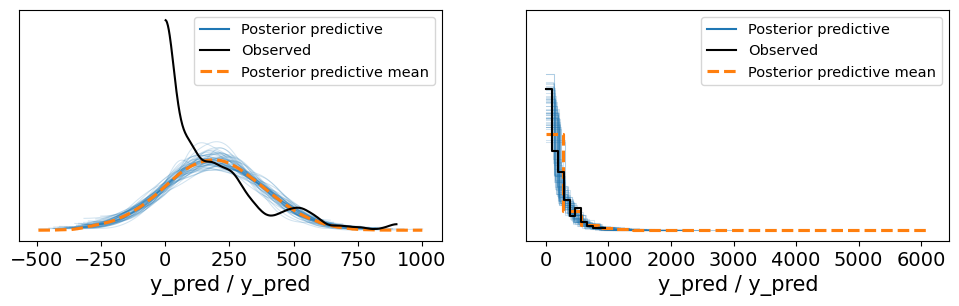

In [36]:
_, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
az.plot_ppc(idata_lb, num_pp_samples=50, ax=axes[0])
az.plot_ppc(idata_neg, num_pp_samples=50, ax=axes[1])

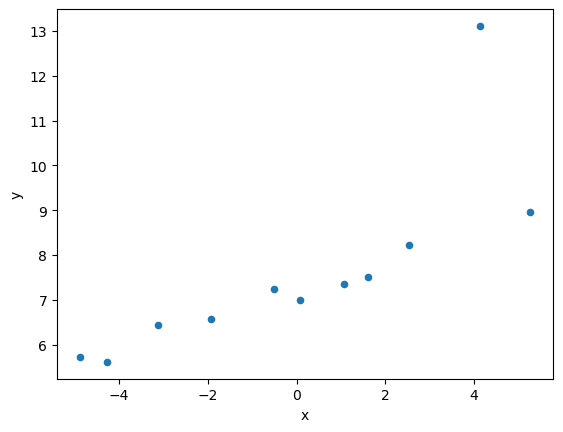

In [37]:
ans = pd.read_csv("data/anscombe_3.csv")
ans.plot("x", "y", kind="scatter");

In [38]:
with pm.Model() as model_t:
    alpha = pm.Normal("alpha", mu=ans.y.mean(), sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=1)
    sigma = pm.HalfNormal("sigma", 5)
    nu_ = pm.Exponential("nu_", 1 / 29)
    nu = pm.Deterministic("nu", nu_ + 1)
    mu = pm.Deterministic("mu", alpha + beta * ans.x)
    _ = pm.StudentT("y_pred", mu=mu, sigma=sigma, nu=nu, observed=ans.y)
    idata_t = pm.sample(2000)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma, nu_]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 6 seconds.


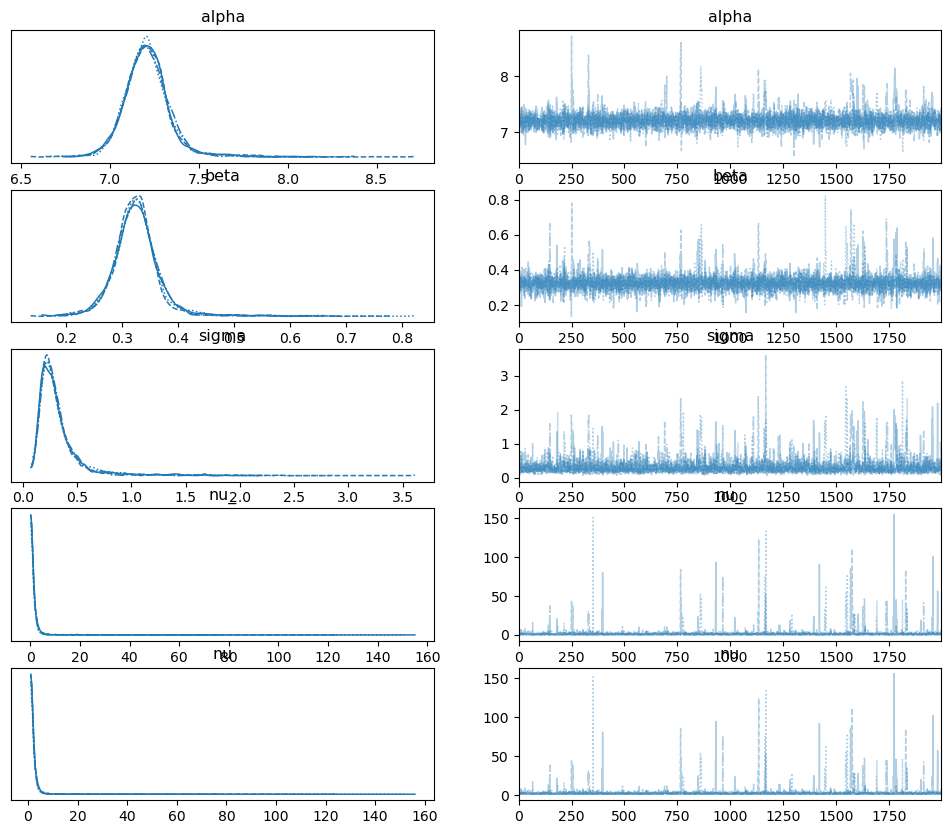

In [39]:
az.plot_trace(idata_t, var_names=["~mu"]);

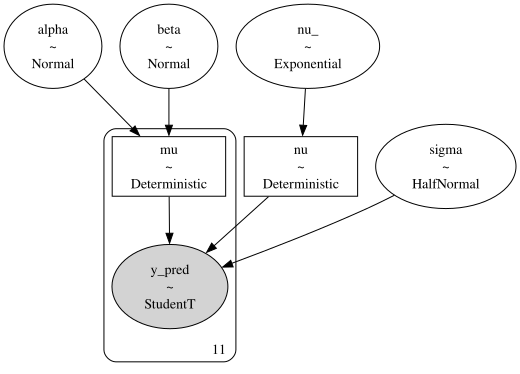

In [40]:
pm.model_to_graphviz(model_t)

In [41]:
beta_c, alpha_c, *_ = linregress(ans.x, ans.y)
display(beta_c)
display(alpha_c)

0.4921764451584281

7.61231889305044

In [42]:

alpha_m = idata_t.posterior['alpha'].mean(("chain", "draw"))
beta_m = idata_t.posterior['beta'].mean(("chain", "draw"))

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


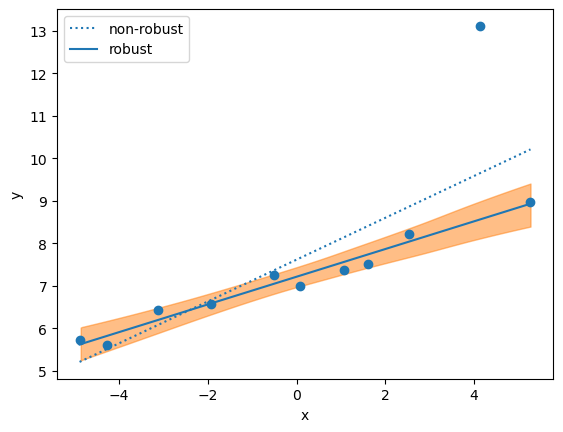

In [43]:
_, ax = plt.subplots()
ax.plot(ans.x, (alpha_c + beta_c * ans.x), "C0:", label="non-robust")
ax.plot(ans.x, ans.y, "C0o")

x_plot = xr.DataArray(np.linspace(ans.x.min(), ans.x.max(), 50), dims="plot_id")
ax.plot(x_plot, alpha_m + beta_m * x_plot, c="C0", label="robust")
az.plot_hdi(ans.x, az.hdi(idata_t.posterior["mu"])['mu'].T, ax=ax)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()


In [44]:
az.summary(idata_t, kind='stats')

,mean,sd,hdi_3%,hdi_97%
alpha,7.210,0.138,6.975,7.442
beta,0.326,0.046,0.248,0.404
sigma,0.322,0.230,0.082,0.631
nu_,1.745,6.204,0.000,3.444
nu,2.745,6.204,1.000,4.444
mu[0],5.616,0.231,5.231,6.012
mu[1],5.818,0.209,5.461,6.169
mu[2],6.191,0.172,5.882,6.475
mu[3],6.584,0.144,6.328,6.823
mu[4],7.047,0.134,6.816,7.271


In [45]:
idata_t.extend(pm.sample_posterior_predictive(idata_t, model=model_t, extend_inferencedata=True))

Sampling: [y_pred]


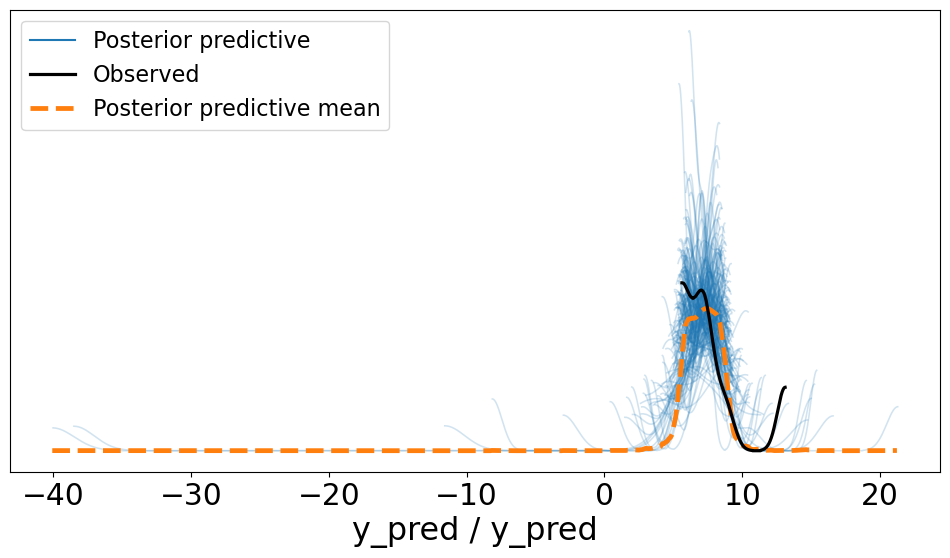

In [46]:

ax = az.plot_ppc(idata_t, num_pp_samples=200, figsize=(12, 6))

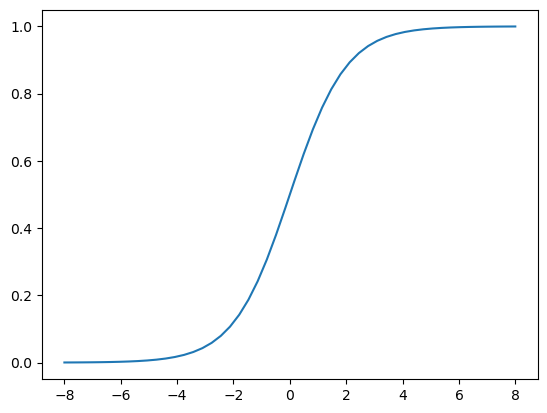

In [47]:
z = np.linspace(-8, 8)
plt.plot(z, 1 / (1 + np.exp(-z)))

In [48]:
iris = pd.read_csv("data/iris.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [49]:
df = iris.query("species == ('setosa', 'versicolor')")
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,versicolor
96,5.7,2.9,4.2,1.3,versicolor
97,6.2,2.9,4.3,1.3,versicolor
98,5.1,2.5,3.0,1.1,versicolor


In [50]:
y_0 = pd.Categorical(df['species']).codes
y_0

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int8)

In [51]:
x_n = "sepal_length"
x_0 = df[x_n].values
x_0

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4,
       6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
       6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7,
       6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5,
       6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7])

In [52]:
x_c = x_0 - x_0.mean()
x_c

array([-0.371, -0.571, -0.771, -0.871, -0.471, -0.071, -0.871, -0.471,
       -1.071, -0.571, -0.071, -0.671, -0.671, -1.171,  0.329,  0.229,
       -0.071, -0.371,  0.229, -0.371, -0.071, -0.371, -0.871, -0.371,
       -0.671, -0.471, -0.471, -0.271, -0.271, -0.771, -0.671, -0.071,
       -0.271,  0.029, -0.571, -0.471,  0.029, -0.571, -1.071, -0.371,
       -0.471, -0.971, -1.071, -0.471, -0.371, -0.671, -0.371, -0.871,
       -0.171, -0.471,  1.529,  0.929,  1.429,  0.029,  1.029,  0.229,
        0.829, -0.571,  1.129, -0.271, -0.471,  0.429,  0.529,  0.629,
        0.129,  1.229,  0.129,  0.329,  0.729,  0.129,  0.429,  0.629,
        0.829,  0.629,  0.929,  1.129,  1.329,  1.229,  0.529,  0.229,
        0.029,  0.029,  0.329,  0.529, -0.071,  0.529,  1.229,  0.829,
        0.129,  0.029,  0.029,  0.629,  0.329, -0.471,  0.129,  0.229,
        0.229,  0.729, -0.371,  0.229])

In [53]:
with pm.Model() as model_lrs:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta = pm.Normal("beta", mu=0, sigma=5)
    mu = alpha + beta * x_c
    theta = pm.Deterministic("theta", pm.math.sigmoid(mu))
    bd = pm.Deterministic("bd", - alpha / beta)
    y1 = pm.Bernoulli("y1", p=theta, observed=y_0)
    idata_lrs = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [54]:
az.summary(idata_lrs)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.270,0.303,-0.303,0.834,0.006,0.004,2956.0,2413.0,1.0
beta,5.191,0.976,3.417,6.948,0.018,0.013,3101.0,2348.0,1.0
theta[0],0.168,0.056,0.073,0.276,0.001,0.001,3430.0,2684.0,1.0
theta[1],0.072,0.036,0.015,0.138,0.001,0.000,3446.0,2577.0,1.0
theta[2],0.029,0.020,0.003,0.067,0.000,0.000,3404.0,2431.0,1.0
...,...,...,...,...,...,...,...,...,...
theta[96],0.804,0.062,0.691,0.921,0.001,0.001,2779.0,2032.0,1.0
theta[97],0.977,0.018,0.945,0.999,0.000,0.000,2833.0,2357.0,1.0
theta[98],0.168,0.056,0.073,0.276,0.001,0.001,3430.0,2684.0,1.0
theta[99],0.804,0.062,0.691,0.921,0.001,0.001,2779.0,2032.0,1.0


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'bd'}>, <Axes: title={'center': 'bd'}>]],
      dtype=object)

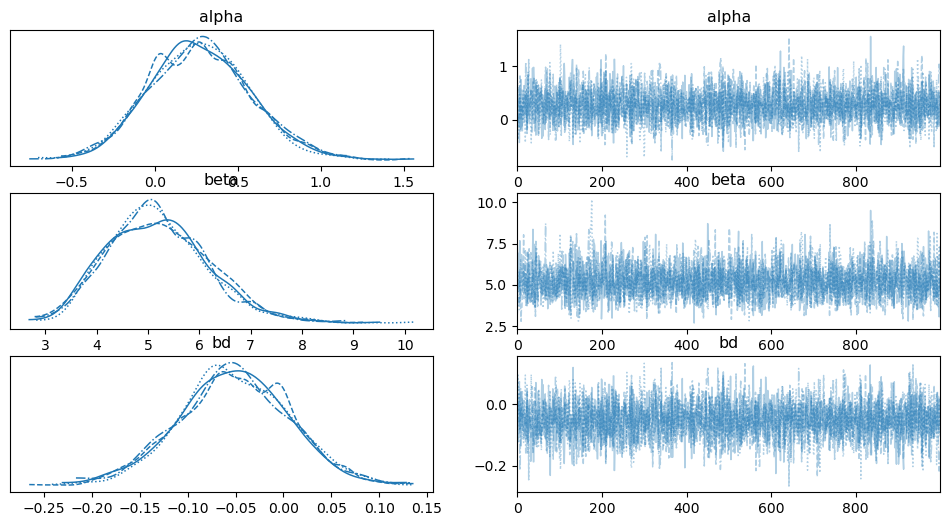

In [55]:
az.plot_trace(idata_lrs, var_names=["~theta"])

In [56]:
posterior = idata_lrs.posterior
theta = posterior["theta"].mean(("chain", "draw"))
idx = np.argsort(x_c)

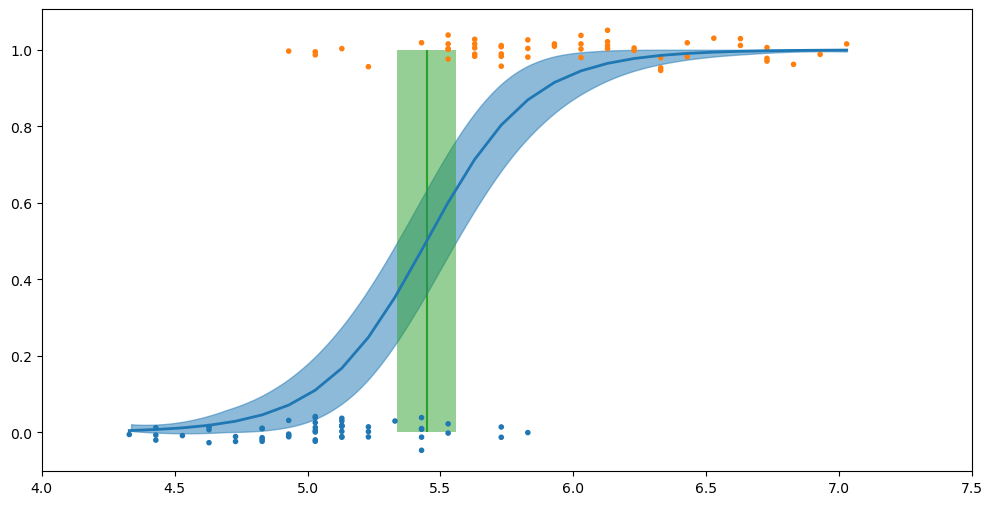

In [57]:
_, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_c[idx], theta[idx], color="C0", lw=2)
ax.vlines(posterior['bd'].mean(("chain", "draw")), 0, 1,  color="C2", zorder=0)
bd_hdi = az.hdi(posterior["bd"])
az.plot_hdi(x_c, posterior['theta'], color='C0', ax=ax)
ax.fill_betweenx([0, 1], bd_hdi['bd'][0], bd_hdi['bd'][1], color="C2", alpha=0.5, lw=0)
ax.scatter(x_c, np.random.normal(y_0, 0.02), marker=".", color=[f"C{x}" for x in y_0])
locs, _ = plt.xticks()
ax.set_xticks(locs, np.round(locs + x_0.mean(), 1))

/tmp/ipykernel_80052/2971192109.py:2: RuntimeWarning: divide by zero encountered in divide
  odds = probability / (1 - probability)


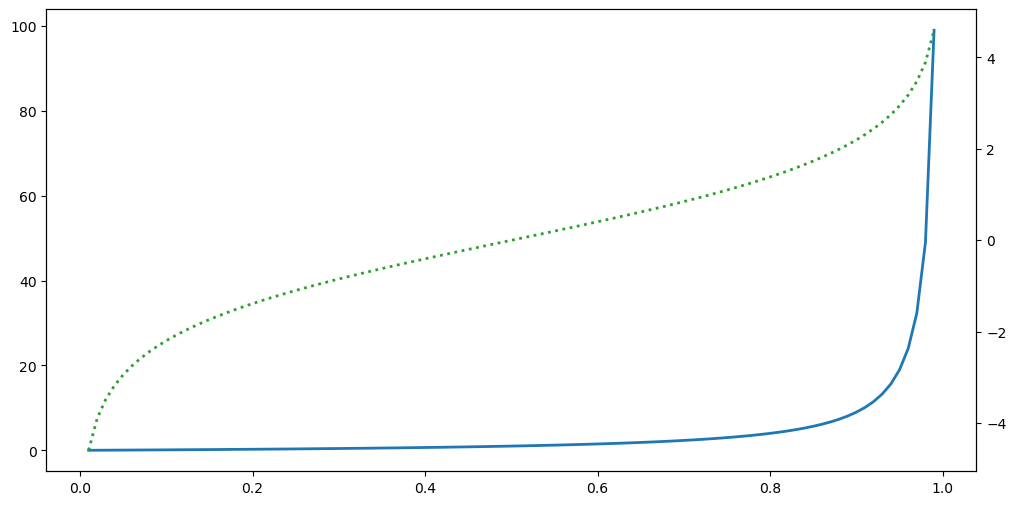

In [58]:
probability = np.linspace(0.01, 1, 100)
odds = probability / (1 - probability)
_, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(probability, odds, "C0", lw=2)
ax2.plot(probability, np.log(odds), "C2:", lw=2)


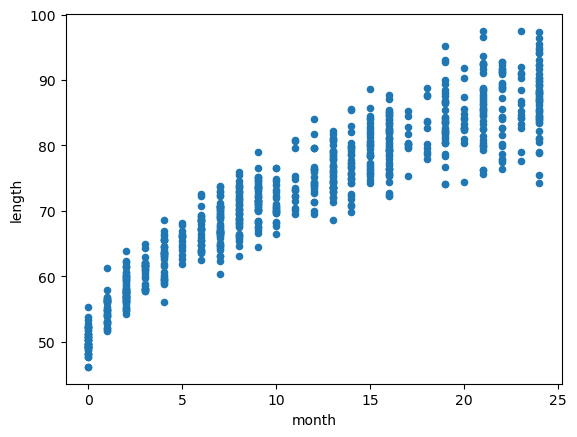

In [59]:
data = pd.read_csv("data/babies.csv")
data.plot.scatter("month", "length");

In [60]:
with pm.Model() as model_vv:
    x_shared = pm.MutableData("x_shared", data.month.values.astype(float))
    alpha = pm.Normal("alpha", sigma=10)
    beta = pm.Normal("beta", sigma=10)
    gamma = pm.HalfNormal("gamma", sigma=10)
    delta = pm.HalfNormal("delta", sigma=10)
    
    mu = pm.Deterministic("mu", alpha + beta * x_shared**0.5)
    sigma = pm.Deterministic("sigma", gamma + delta * x_shared)

    y_pred = pm.Normal("y_pred", mu=mu, sigma=sigma, observed=data.length)
    idata_vv = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma, delta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


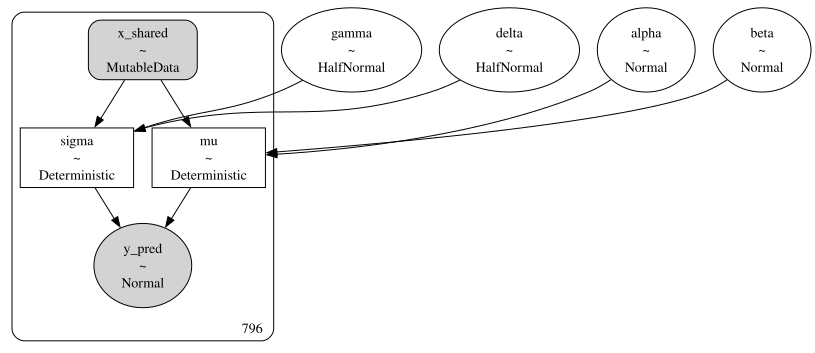

In [61]:
pm.model_to_graphviz(model_vv)

In [62]:
idata_vv

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [63]:
az.summary(idata_vv)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,48.028,0.237,47.576,48.473,0.005,0.004,1914.0,2028.0,1.0
beta,7.873,0.086,7.704,8.031,0.002,0.001,1890.0,1927.0,1.0
gamma,2.293,0.123,2.066,2.524,0.003,0.002,2150.0,2289.0,1.0
delta,0.112,0.012,0.092,0.135,0.000,0.000,2055.0,2326.0,1.0
mu[0],48.028,0.237,47.576,48.473,0.005,0.004,1914.0,2028.0,1.0
...,...,...,...,...,...,...,...,...,...
sigma[791],4.986,0.202,4.599,5.353,0.004,0.003,2675.0,3010.0,1.0
sigma[792],4.986,0.202,4.599,5.353,0.004,0.003,2675.0,3010.0,1.0
sigma[793],4.986,0.202,4.599,5.353,0.004,0.003,2675.0,3010.0,1.0
sigma[794],4.986,0.202,4.599,5.353,0.004,0.003,2675.0,3010.0,1.0


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'gamma'}>,
        <Axes: title={'center': 'gamma'}>],
       [<Axes: title={'center': 'delta'}>,
        <Axes: title={'center': 'delta'}>]], dtype=object)

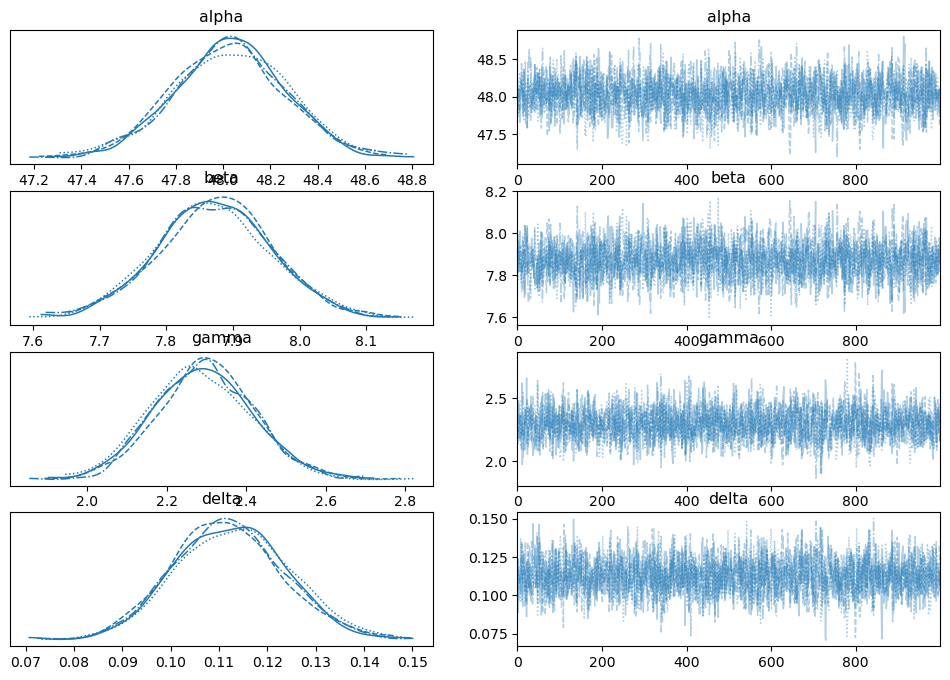

In [64]:
az.plot_trace(idata_vv, var_names=["alpha", "beta", "gamma", "delta"])

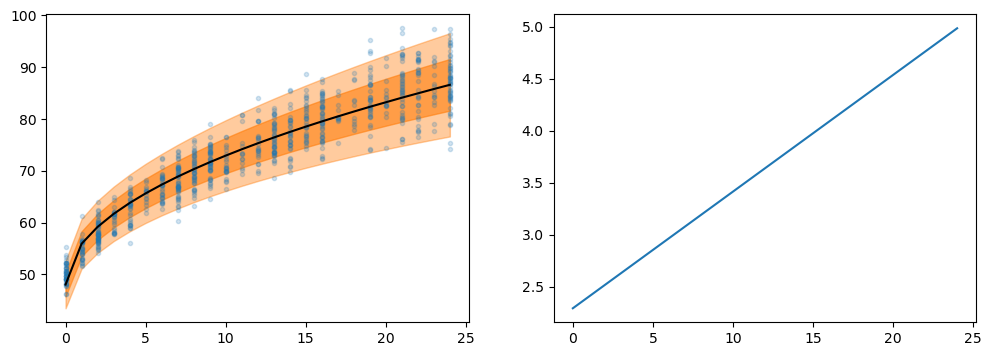

In [69]:
_, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(data.month, data.length, "C0.", alpha=0.2)

posterior = az.extract(idata_vv)

mu_m = posterior["mu"].mean("sample").values
sigma_m = posterior["sigma"].mean("sample").values

axes[0].plot(data.month, mu_m, c="k")
axes[0].fill_between(data.month, mu_m + 1 * sigma_m, mu_m - 1 * sigma_m, alpha=0.6, color="C1")
axes[0].fill_between(data.month, mu_m + 2 * sigma_m, mu_m - 2 * sigma_m, alpha=0.4, color="C1")

axes[1].plot(data.month, sigma_m)

In [70]:
with model_vv:
    pm.set_data({"x_shared": [0.5]})
    ppc = pm.sample_posterior_predictive(idata_vv, random_seed=123)
    y_ppc = ppc.posterior_predictive["y_pred"].stack(sample=("chain","draw"))

Sampling: [y_pred]


In [71]:
y_ppc

<xarray.DataArray 'y_pred' (y_pred_dim_2: 796, sample: 4000)>
array([[52.36850078, 57.16832616, 54.41339632, ..., 54.70297971,
        53.11799269, 57.40863532],
       [53.59164053, 55.43700161, 58.08473524, ..., 53.1151614 ,
        53.01910558, 54.01677018],
       [53.44507936, 50.33929266, 53.99972134, ..., 51.74029159,
        52.71492089, 57.71371912],
       ...,
       [55.77865968, 51.50596613, 50.63640072, ..., 52.41127073,
        54.4151084 , 51.04961622],
       [53.01816085, 51.93932011, 52.26453814, ..., 56.27450183,
        55.50807038, 55.66097098],
       [56.76703804, 53.8571768 , 53.84290282, ..., 53.24668525,
        52.01396063, 52.19509423]])
Coordinates:
  * y_pred_dim_2  (y_pred_dim_2) int64 0 1 2 3 4 5 6 ... 790 791 792 793 794 795
  * sample        (sample) object MultiIndex
  * chain         (sample) int64 0 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3 3
  * draw          (sample) int64 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999

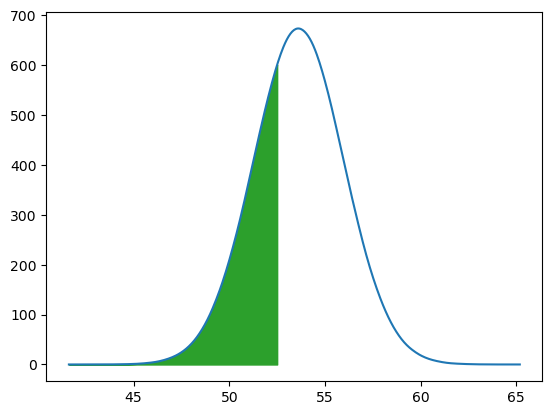

In [73]:
ref = 52.5
grid, pdf = az.stats.density_utils._kde_linear(y_ppc.values)
plt.plot(grid, pdf)
percentile = int((y_ppc <= ref).mean() * 100)
plt.fill_between(
    grid[grid < ref],
    pdf[grid < ref],
    label="percentile = {:2d}".format(percentile),
    color="C2",
)

Hierarchical linear regresstion

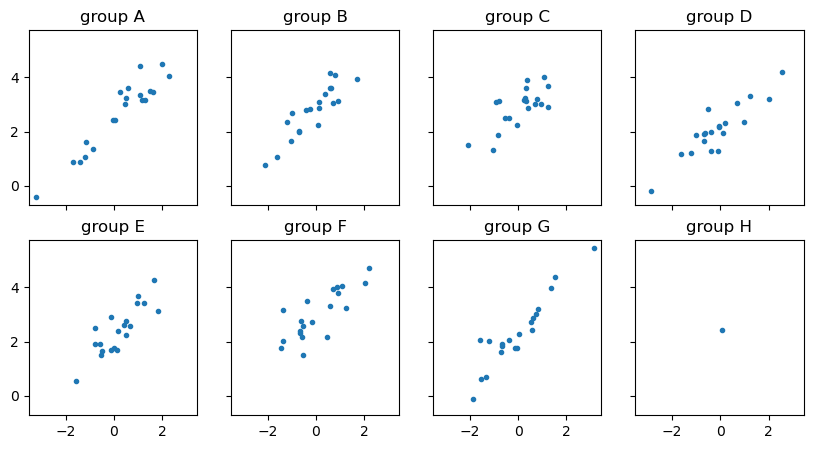

In [141]:
N = 20
groups = ["A", "B", "C", "D", "E", "F", "G", "H"]
M = len(groups)
idx = np.repeat(range(M - 1), N)
idx = np.append(idx, 7)
np.random.seed(314)
alpha_real = np.random.normal(2.5, 0.5, size=M)
beta_real = np.random.beta(6, 1, size=M)
eps_real = np.random.normal(0, 0.5, size=len(idx))
y_m = np.zeros(len(idx))
x_m = np.random.normal(0, 1, len(idx))
y_m = alpha_real[idx] + beta_real[idx] * x_m + eps_real
_, ax = plt.subplots(2, 4, figsize=(10, 5), sharex=True, sharey=True)
ax = np.ravel(ax)
j, k = 0, N
for i, g in enumerate(groups):
    ax[i].scatter(x_m[j:k], y_m[j:k], marker=".")
    ax[i].set_title(f"group {g}")

    j += N
    k += N

In [142]:
coords = {"group": groups}

with pm.Model(coords=coords) as unpooled_model:
    alpha = pm.Normal("alpha", mu=0, sigma=10, dims="group")
    beta = pm.Normal("beta", mu=0, sigma=10, dims="group")
    sigma = pm.HalfNormal("sigma", 5)
    mu = pm.Deterministic("mu", alpha[idx] + beta[idx] * x_m)
    _ = pm.Normal("y_pred", mu=mu, sigma=sigma, observed=y_m)
    idata_up = pm.sample(random_seed=123)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


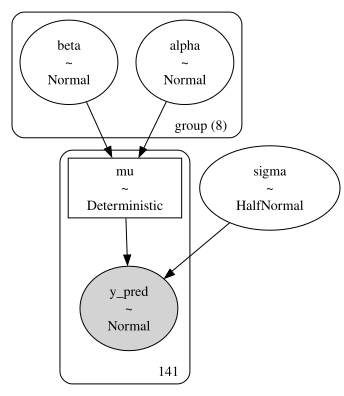

In [143]:
unpooled_model.to_graphviz()

In [144]:
az.summary(idata_up, var_names=["alpha", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[A],2.464,0.108,2.259,2.665,0.001,0.001,8005.0,2464.0,1.0
alpha[B],2.878,0.108,2.679,3.073,0.001,0.001,8589.0,2816.0,1.0
alpha[C],2.864,0.108,2.669,3.075,0.001,0.001,9494.0,3239.0,1.0
alpha[D],2.177,0.108,1.974,2.374,0.001,0.001,9305.0,3276.0,1.0
alpha[E],2.255,0.110,2.052,2.467,0.001,0.001,8324.0,3254.0,1.0
alpha[F],2.957,0.106,2.755,3.160,0.001,0.001,6028.0,3056.0,1.0
alpha[G],2.367,0.108,2.167,2.575,0.001,0.001,9654.0,2778.0,1.0
alpha[H],2.433,0.713,1.023,3.702,0.010,0.007,4843.0,3386.0,1.0
beta[A],0.897,0.077,0.755,1.039,0.001,0.001,9445.0,2975.0,1.0
beta[B],0.874,0.116,0.656,1.089,0.001,0.001,8699.0,2958.0,1.0


(-20.0, 30.0)

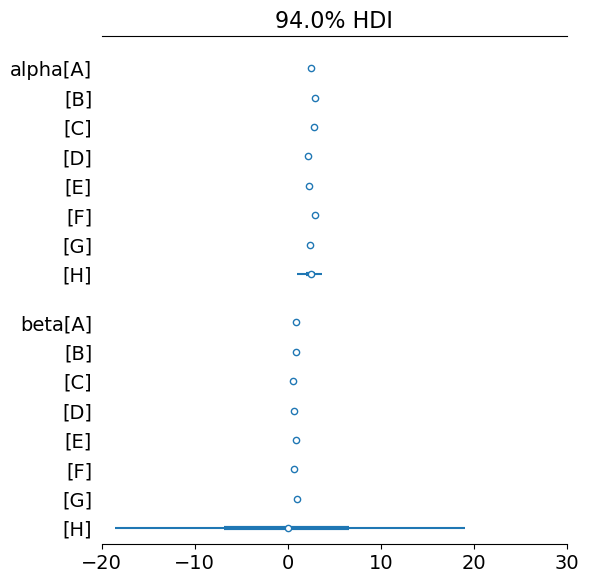

In [145]:
ax = az.plot_forest(idata_up, var_names=["alpha", "beta"], combined=True)
ax[0].set_xlim(-20, 30)


In [146]:
with pm.Model(coords=coords) as hierarchical_contered:
    # hyperpriors
    alpha_mu = pm.Normal("alpha_mu", mu=y_m.mean(), sigma=1.)
    alpha_sigma = pm.HalfNormal("alpha_sigma", 5)
    beta_mu = pm.Normal("beta_mu", mu=0, sigma=1.)
    beta_sigma = pm.HalfNormal("beta_sigma", sigma=5)

    # prior
    alpha = pm.Normal("alpha", mu=alpha_mu, sigma=alpha_sigma, dims='group')
    beta = pm.Normal("beta", mu=beta_mu, sigma=beta_sigma, dims='group')
    sigma = pm.HalfNormal("sigma", 5)
    _ = pm.Normal("y_pred", mu=alpha[idx] + beta[idx] * x_m, sigma=sigma, observed=y_m)
    idata_cen = pm.sample(target_accept=0.99)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_mu, alpha_sigma, beta_mu, beta_sigma, alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
There were 21 divergences after tuning. Increase `target_accept` or reparameterize.


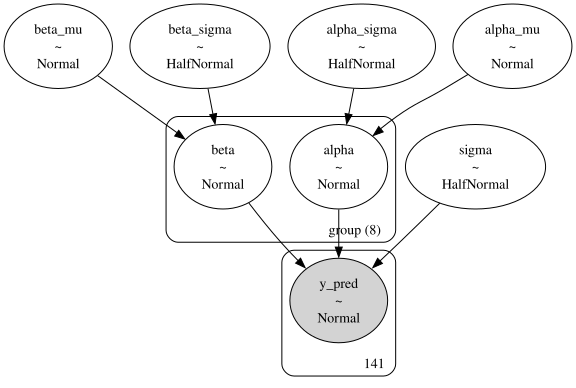

In [147]:
hierarchical_contered.to_graphviz()

In [148]:
az.summary(idata_cen, var_names=["alpha", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[A],2.480,0.103,2.274,2.658,0.002,0.001,2959.0,1293.0,1.00
alpha[B],2.844,0.102,2.653,3.034,0.002,0.001,4608.0,3222.0,1.00
alpha[C],2.823,0.105,2.632,3.023,0.002,0.001,4719.0,2843.0,1.00
alpha[D],2.219,0.110,2.011,2.423,0.002,0.001,3340.0,2532.0,1.00
alpha[E],2.299,0.107,2.097,2.498,0.002,0.001,3774.0,2365.0,1.00
alpha[F],2.909,0.105,2.721,3.112,0.002,0.001,3251.0,3114.0,1.00
alpha[G],2.382,0.103,2.165,2.551,0.002,0.001,4684.0,2845.0,1.00
alpha[H],2.504,0.299,1.912,3.052,0.005,0.004,3404.0,2484.0,1.00
beta[A],0.859,0.068,0.737,0.988,0.001,0.001,2538.0,2927.0,1.00
beta[B],0.835,0.085,0.682,1.003,0.002,0.001,3134.0,2616.0,1.01


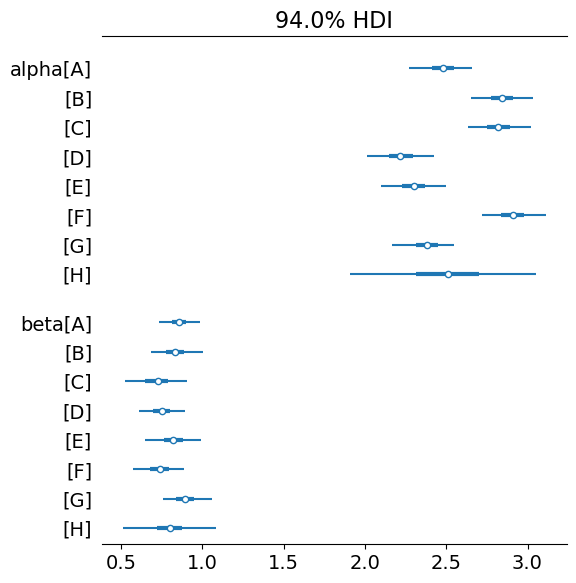

In [150]:
ax = az.plot_forest(idata_cen, var_names=["alpha", "beta"], combined=True)
# ax[0].set_xlim(-20, 30)

In [151]:
with pm.Model(coords=coords) as hierarchical_non_centered:
    # hyperpriors
    alpha_mu = pm.Normal("alpha_mu", mu=y_m.mean(), sigma=1)
    alpha_sigma = pm.HalfNormal("alpha_sigma", 5)
    beta_mu = pm.Normal("beta_mu", mu=0, sigma=1)
    beta_sigma = pm.HalfNormal("beta_sigma", 5)

    # prior
    alpha = pm.Normal("alpha", mu=alpha_mu, sigma=alpha_sigma, dims='group')
    beta_offset = pm.Normal("beta_offset", mu=0, sigma=1, dims='group')
    beta = pm.Deterministic("beta", beta_mu + beta_offset * beta_sigma, dims='group')

    sigma = pm.HalfNormal("sigma", 5)
    _ = pm.Normal("y_pred", mu=alpha[idx] + beta[idx] * x_m, sigma=sigma, observed=y_m)
    idata_ncen = pm.sample(target_accept=0.95)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_mu, alpha_sigma, beta_mu, beta_sigma, alpha, beta_offset, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.


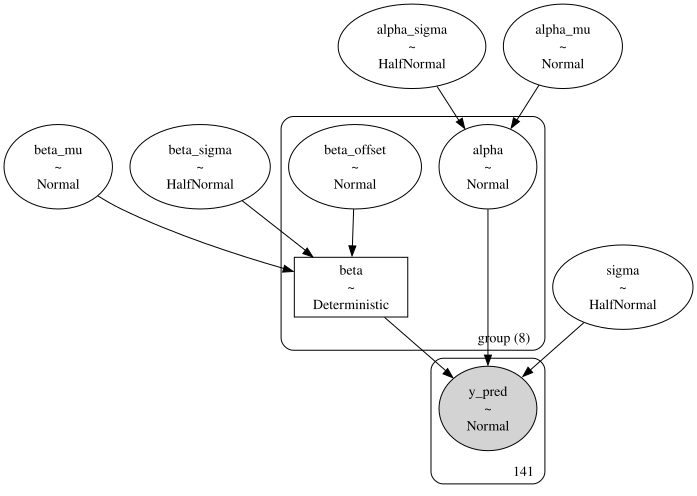

In [152]:
hierarchical_non_centered.to_graphviz()

In [153]:
az.summary(idata_ncen, var_names=["alpha", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[A],2.485,0.102,2.291,2.670,0.002,0.001,4051.0,2833.0,1.0
alpha[B],2.839,0.107,2.657,3.061,0.002,0.001,4659.0,2970.0,1.0
alpha[C],2.824,0.107,2.619,3.015,0.002,0.001,4506.0,2807.0,1.0
alpha[D],2.221,0.109,2.012,2.417,0.002,0.001,4047.0,2710.0,1.0
alpha[E],2.295,0.107,2.092,2.488,0.002,0.001,4142.0,3049.0,1.0
alpha[F],2.912,0.104,2.718,3.109,0.001,0.001,5467.0,3250.0,1.0
alpha[G],2.388,0.103,2.200,2.585,0.002,0.001,4547.0,3243.0,1.0
alpha[H],2.507,0.309,1.914,3.100,0.005,0.004,3349.0,2779.0,1.0
beta[A],0.856,0.068,0.728,0.978,0.001,0.001,3591.0,3571.0,1.0
beta[B],0.832,0.086,0.669,1.002,0.001,0.001,5009.0,3451.0,1.0


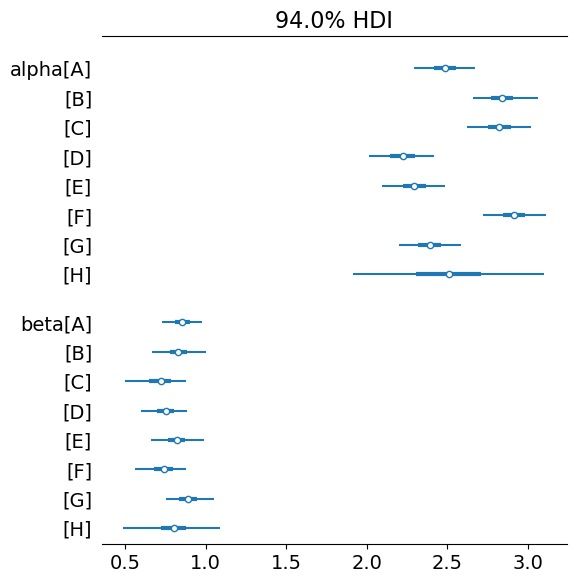

In [155]:
ax = az.plot_forest(idata_ncen, var_names=["alpha", "beta"], combined=True)
# ax[0].set_xlim(-20, 30)

/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/opt/conda/envs/bap3/lib/python3.11/site-packages/arviz/plots/hdiplot.py:160: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)
/opt/conda/envs/bap3/l

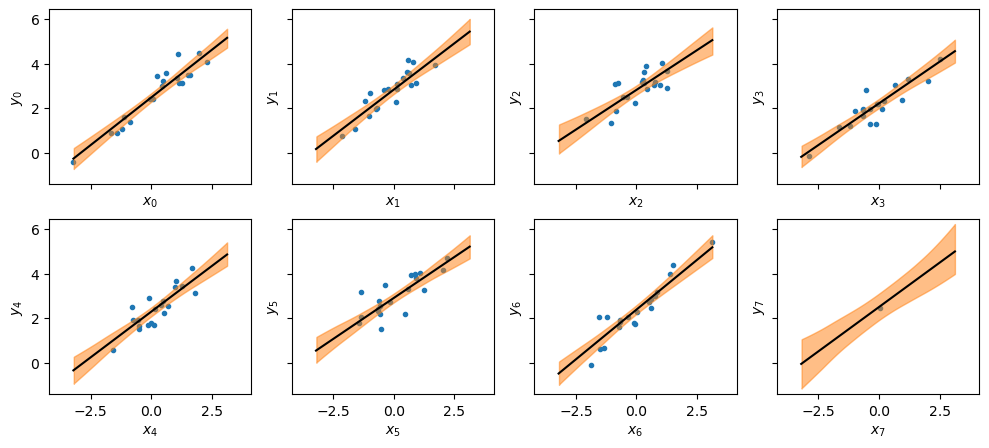

In [157]:
from tokenize import group


_, ax = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
ax = np.ravel(ax)
j, k = 0, N
x_range = np.linspace(x_m.min(), x_m.max(), 10)
posterior = az.extract(idata_ncen)

for i, g in enumerate(groups):
    ax[i].scatter(x_m[j:k], y_m[j:k], marker='.')
    ax[i].set_xlabel(f"$x_{i}$")
    ax[i].set_ylabel(f"$y_{i}$")
    alphas = posterior["alpha"].sel(group=g)
    betas = posterior["beta"].sel(group=g)
    alpha_m = alphas.mean("sample").item()
    beta_m = betas.mean("sample").item()
    ax[i].plot(x_range, alpha_m + beta_m * x_range, c="k")
    az.plot_hdi(x_range, alphas + betas * xr.DataArray(x_range).transpose(), ax=ax[i])
    plt.xlim(x_m.min() - 1, x_m.max() + 1)
    plt.ylim(y_m.min() - 1, y_m.max() + 1)

    j += N
    k += N

Multiple linear regression

In [159]:
with pm.Model() as model_mlb:
    alpha = pm.Normal("alpha", mu=0, sigma=1)
    beta0 = pm.Normal("beta0", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", 10)
    mu = pm.Deterministic("mu", 
                          pm.math.exp(alpha + beta0 * bikes.temperature + beta1 * bikes.hour))
    _ = pm.NegativeBinomial("y_pred", mu=mu, alpha=sigma, observed=bikes.rented)
    idata_mlb = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta0, beta1, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


In [162]:
az.summary(idata_mlb, var_names=["alpha", "beta0", "beta1"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,3.551,0.134,3.298,3.803,0.003,0.002,2493.0,1972.0,1.0
beta0,0.038,0.006,0.026,0.049,0.000,0.000,2383.0,1946.0,1.0
beta1,0.082,0.010,0.065,0.101,0.000,0.000,2759.0,2334.0,1.0


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta0'}>,
        <Axes: title={'center': 'beta0'}>],
       [<Axes: title={'center': 'beta1'}>,
        <Axes: title={'center': 'beta1'}>]], dtype=object)

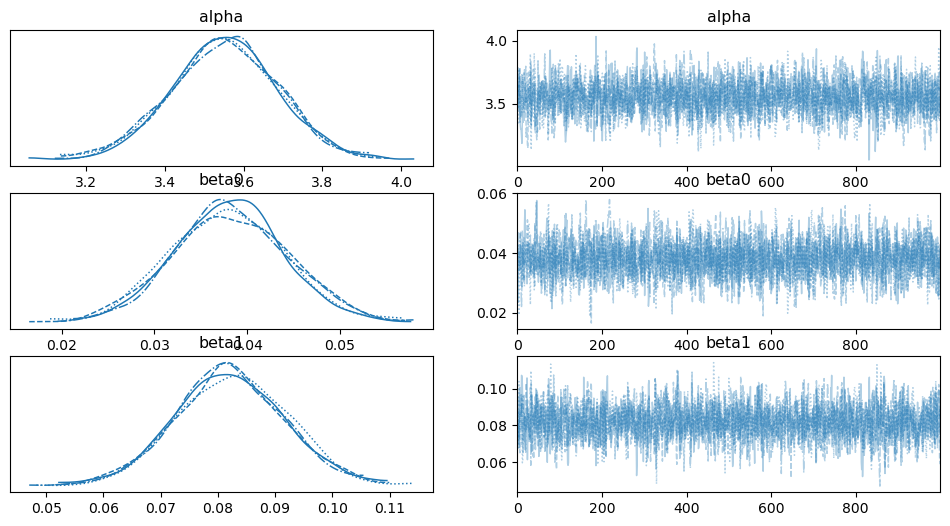

In [163]:
az.plot_trace(idata_mlb, var_names=["alpha", "beta0", "beta1"])

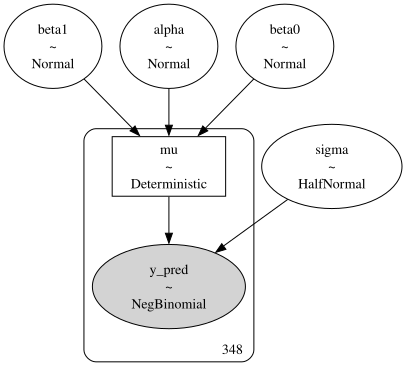

In [164]:
model_mlb.to_graphviz()

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

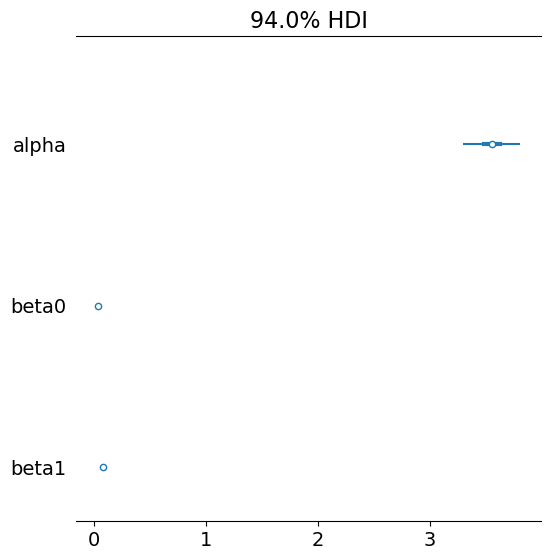

In [166]:
az.plot_forest(idata_mlb, var_names=["alpha", "beta0", "beta1"], combined=True)